In [2]:
!pip install scikit-learn

In [3]:
#load database

In [1]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load featured data from database
conn = sqlite3.connect("data/stocks.db")
df = pd.read_sql("""
    SELECT Close, MA7, MA20, MA50, RSI14,
           MACD_hist, BB_width, price_to_MA20,
           Close_lag1, Close_lag2, Close_lag5,
           daily_return, Target
    FROM RELIANCE
    WHERE Target IS NOT NULL
""", conn)
conn.close()

print(f"Loaded {len(df)} rows for training")

C:\Users\satyanarayan kumawat\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded 1185 rows for training


In [2]:
#split into train & tests sets

In [3]:
X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Training rows : 948
Testing rows  : 237


In [4]:
# Train Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("── Linear Regression ──")
print(f"RMSE : {rmse_lr:.2f}")
print(f"MAE  : {mae_lr:.2f}")

── Linear Regression ──
RMSE : 12.40
MAE  : 9.46


In [6]:
#Train Random Forest 

In [7]:
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=10,       # prevents overfitting
    random_state=42    # reproducible results
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("── Random Forest ──")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")

── Random Forest ──
RMSE : 16.58
MAE  : 13.03


In [8]:
#Plot predicted vs actual prices

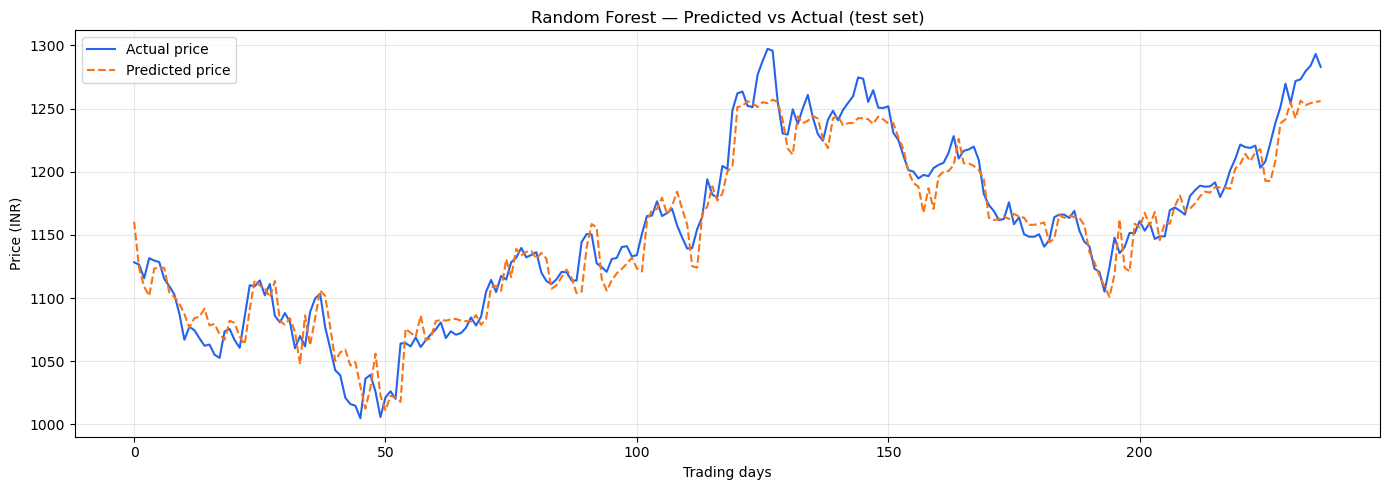


Best model: Random Forest
RMSE: 16.58 INR  |  MAE: 13.03 INR


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.values,  color="#2563eb", linewidth=1.5, label="Actual price")
ax.plot(y_pred_rf,      color="#f97316", linewidth=1.5, label="Predicted price", linestyle="--")

ax.set_title("Random Forest — Predicted vs Actual (test set)")
ax.set_xlabel("Trading days")
ax.set_ylabel("Price (INR)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("charts/predicted_vs_actual.png", dpi=150)
plt.show()

print(f"\nBest model: Random Forest")
print(f"RMSE: {rmse_rf:.2f} INR  |  MAE: {mae_rf:.2f} INR")

In [10]:
# Run this to see your error as a percentage of average price
avg_price = y_test.mean()
rmse_pct = (rmse_rf / avg_price) * 100
mae_pct  = (mae_rf  / avg_price) * 100

print(f"Average test price : ₹{avg_price:.2f}")
print(f"RMSE as % of price : {rmse_pct:.2f}%")
print(f"MAE  as % of price : {mae_pct:.2f}%")

Average test price : ₹1153.60
RMSE as % of price : 1.44%
MAE  as % of price : 1.13%


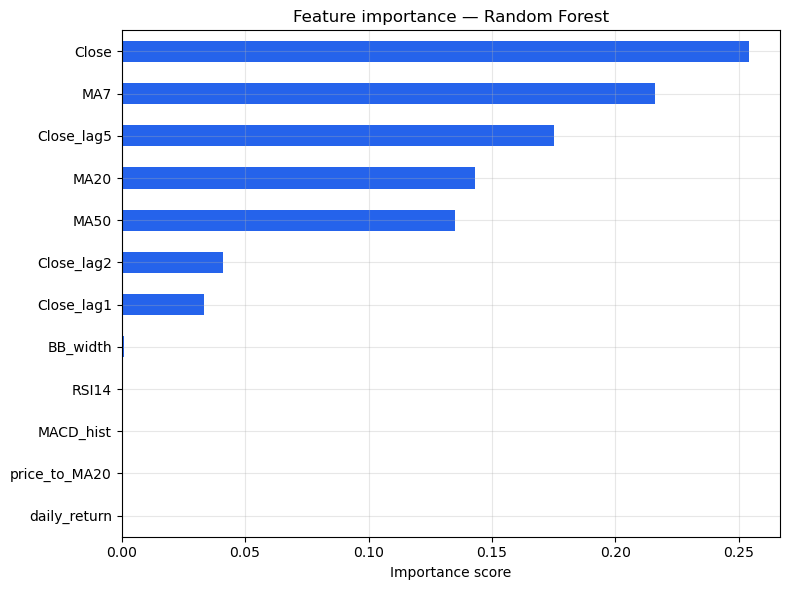

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from Random Forest
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Feature importance — Random Forest")
ax.set_xlabel("Importance score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=150)
plt.show()

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compare train vs test error — key overfitting check
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print("── Overfitting check ──")
print(f"Train RMSE : {rmse_train:.2f}")
print(f"Test RMSE  : {rmse_test:.2f}")
print(f"Difference : {rmse_test - rmse_train:.2f}")

# Rule of thumb: if test RMSE >> train RMSE, model is overfitting
if (rmse_test - rmse_train) / rmse_train > 0.5:
    print("⚠ Possible overfitting — consider reducing max_depth")
else:
    print("✓ Model generalises well")

── Overfitting check ──
Train RMSE : 7.48
Test RMSE  : 16.58
Difference : 9.10
⚠ Possible overfitting — consider reducing max_depth


In [13]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# TimeSeriesSplit respects time order — never shuffles
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    rmse_scores.append(rmse)
    print(f"Fold {fold} RMSE: {rmse:.2f}")

print(f"\nMean RMSE : {np.mean(rmse_scores):.2f}")
print(f"Std RMSE  : {np.std(rmse_scores):.2f}")

Fold 1 RMSE: 173.45
Fold 2 RMSE: 42.61
Fold 3 RMSE: 110.53
Fold 4 RMSE: 18.20
Fold 5 RMSE: 16.90

Mean RMSE : 72.34
Std RMSE  : 60.94


In [14]:
# Try different depths and find the best one
depths = [3, 5, 7, 10, 15, None]
results = []

for depth in depths:
    model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))
    results.append({"max_depth": depth, "train_rmse": train_rmse, "test_rmse": test_rmse})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_depth = results_df.loc[results_df["test_rmse"].idxmin(), "max_depth"]
print(f"\nBest max_depth: {best_depth}")

 max_depth  train_rmse  test_rmse
       3.0   26.154786  40.199556
       5.0   14.504560  15.749850
       7.0   10.605775  16.182781
      10.0    7.480896  16.579699
      15.0    6.760224  16.563482
       NaN    6.742593  16.517645

Best max_depth: 5.0


In [15]:
# Fix: convert to int before passing to the model
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=int(best_depth) if best_depth is not None else None,
    random_state=42
)
final_model.fit(X_train, y_train)
y_final = final_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_final))
final_mae  = mean_absolute_error(y_test, y_final)
avg_price  = y_test.mean()

print("── Final model results ──")
print(f"RMSE          : {final_rmse:.2f} INR")
print(f"MAE           : {final_mae:.2f} INR")
print(f"Error %       : {(final_rmse/avg_price)*100:.2f}%")
print(f"Avg test price: {avg_price:.2f} INR")

── Final model results ──
RMSE          : 15.76 INR
MAE           : 12.27 INR
Error %       : 1.37%
Avg test price: 1153.60 INR
